In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mygene

# Gene expression

## OSCC

### Kretzschmar lab

In [95]:
oscc_kk_gex = pd.read_csv(
    "data/validation_data/oscc_organoids/in_house_PDO_counts.csv",
    index_col=0
)

In [96]:
oscc_kk_gex.head()

,P9-M-LN,P20-T-G,P47-T-T,P47-R-AP,P48-M-LN,P55-M-LN,P102-T-LT,P109-T-LT,G9-M-LN,G61-T-LT,G61-M-LN,G73-T-DT,G73-M-LN,G16-T-AP,G47-T-T,G47-R-AP,G50-T-SP,G55-M-LN
ISG15,3,34,12,15,2,12,3,0,39,328,27,320,160,250,266,63,277,128
UBE2J2,54,54,91,76,10,39,7,5,173,313,339,577,762,231,245,192,456,856
C1orf159,12,9,13,12,16,12,26,246,21,63,111,156,157,46,94,58,82,371
TTLL10,0,6,1,1,95,368,112,182,5,0,2,4,13,6,0,8,4,34
ACAP3,37,28,23,17,23,66,22,9,284,384,404,622,1011,348,461,421,549,1477


### Driehuis 2019 Cancer Discovery

In [7]:
oscc_dcd_gex = pd.read_csv(
    "data/validation_data/PDOs/Driehuis_2019_CancerDiscv_OSCC/driehuis_OSCC_org_raw_counts.csv",
    index_col=0
)

oscc_dcd_gex.head()

,N13,N12,N6,T2,T6,T3_1,T1_1,T4,N35,N31,N27,N8,T8,N5,T5,N10,T1_2,T3_2
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A1BG__chr19,7.0,3.0,0.0,0.0,10.0,6.0,10.0,6.0,30.0,8.0,14.0,1.0,0.0,0.0,4.0,0.0,6.0,1.0
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A1CF__chr10,0.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
oscc_dcd_gex = oscc_dcd_gex.dropna()

In [9]:
oscc_dcd_gex.index = oscc_dcd_gex.index.str.split("__", expand=True).get_level_values(0)

## Bladder cancer

### BLCa GSE103990

In [10]:
blca_gex = pd.read_csv(
    "data/validation_data/PDOs/BLCa_GSE103990/GSE103990_raw_counts_GRCh38.p13_NCBI.tsv.gz",
    index_col=0,
    sep="\t"
)

In [11]:
blca_gex.head()

,GSM2787431,GSM2787432,GSM2787433,GSM2787434,GSM2787435,GSM2787436,GSM2787437,GSM2787438,GSM2787439,GSM2787440,...,GSM2787460,GSM2787461,GSM2787462,GSM2787465,GSM2787466,GSM2787468,GSM2787469,GSM2787470,GSM2787471,GSM2787472
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21,19,1,7,6,9,11,27,8,5,...,21,13,5,6,4,8,11,8,9,4
653635,609,631,337,894,548,430,547,496,1012,342,...,1290,828,483,638,790,157,189,93,258,77
102466751,17,17,9,4,21,21,29,9,6,11,...,10,55,20,11,44,5,14,6,8,4
107985730,2,3,0,0,2,0,4,1,0,0,...,0,2,0,0,0,1,0,0,0,0
100302278,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#########################################
#
#   SETTING ORGANOID NAMES FROM PUBLICATION
#
#########################################

In [12]:
metadata_blca = pd.read_csv(
    "data/validation_data/PDOs/BLCa_GSE103990/GSE103990_series_matrix.txt",
    skiprows=30,
    index_col=0,
    sep="\t"
)

In [13]:
metadata_blca.head()

,SCBO-5_orgP10,SCBO-5_orgP13,SCBO-1_orgP7,SCBO-3_orgP4,SCBO-6_orgP4,SCBO-2_orgP5,SCBO-4_orgP10,SCBO-5_orgP3,SCBO-3.2_orgP1,SCBO-7_orgP0,...,SCBO-7.2_orgP1,SCBO-14_orgP10,SCBO-16_tumor,SCBO-7.2_tumor,SCBO-5_tumor,SCBO-7_tumor,SCBO-9_tumor,SCBO-11_tumor,SCBO-12_tumor,SCBO-15_tumor
!Sample_title,,,,,,,,,,,,,,,,,,,,,
!Sample_geo_accession,GSM2787431,GSM2787432,GSM2787433,GSM2787434,GSM2787435,GSM2787436,GSM2787437,GSM2787438,GSM2787439,GSM2787440,...,GSM2787463,GSM2787464,GSM2787465,GSM2787466,GSM2787467,GSM2787468,GSM2787469,GSM2787470,GSM2787471,GSM2787472
!Sample_status,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,...,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018,Public on Apr 09 2018
!Sample_submission_date,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,...,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017,Sep 19 2017
!Sample_last_update_date,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,...,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019,May 15 2019
!Sample_type,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,...,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA


In [14]:
sample_names = metadata_blca.iloc[0,:]
sample_names = pd.Series(sample_names.index, index=sample_names.values)

In [15]:
# setting organoid names from paper
blca_gex.columns = blca_gex.columns.map(sample_names)

In [ ]:
#########################################
#
#   CONVERTING GENEID TO GENE SYMBOL
#
#########################################

In [16]:
mg = mygene.MyGeneInfo()

In [17]:
output = mg.querymany(
    blca_gex.index.to_list(),
    scopes = "entrezgene",
    fields = "symbol",
    species = "human"
)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1703 input query terms found no hit:	['107985721', '100133331', '107984841', '107984847', '107984849', '112267874', '107984868', '1053786


In [18]:
genes = pd.DataFrame(output)

In [19]:
genes["notfound"] = genes.notfound.fillna(False)
genes = genes.loc[genes.notfound == False,:]

/tmp/ipykernel_4292/1621788054.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  genes["notfound"] = genes.notfound.fillna(False)


In [20]:
genes.head()

,query,_id,_score,symbol,notfound
0,100287102,100287102,8.789937,DDX11L1,False
1,653635,653635,8.789944,WASH7P,False
2,102466751,102466751,27.248804,MIR6859-1,False
3,107985730,107985730,27.248804,MIR1302-2HG,False
4,100302278,100302278,27.248804,MIR1302-2,False


In [21]:
blca_gex.index =  (
    blca_gex.index
    .astype("str")
    .map(genes.set_index("query").symbol)
)

In [22]:
blca_gex.head()

,SCBO-5_orgP10,SCBO-5_orgP13,SCBO-1_orgP7,SCBO-3_orgP4,SCBO-6_orgP4,SCBO-2_orgP5,SCBO-4_orgP10,SCBO-5_orgP3,SCBO-3.2_orgP1,SCBO-7_orgP0,...,SCBO-3_orgP14,SCBO-16_orgP4,SCBO-11.3_orgP2,SCBO-16_tumor,SCBO-7.2_tumor,SCBO-7_tumor,SCBO-9_tumor,SCBO-11_tumor,SCBO-12_tumor,SCBO-15_tumor
GeneID,,,,,,,,,,,,,,,,,,,,,
DDX11L1,21,19,1,7,6,9,11,27,8,5,...,21,13,5,6,4,8,11,8,9,4
WASH7P,609,631,337,894,548,430,547,496,1012,342,...,1290,828,483,638,790,157,189,93,258,77
MIR6859-1,17,17,9,4,21,21,29,9,6,11,...,10,55,20,11,44,5,14,6,8,4
MIR1302-2HG,2,3,0,0,2,0,4,1,0,0,...,0,2,0,0,0,1,0,0,0,0
MIR1302-2,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Pancreatic cancer

### Driehuis 2019 PNAS

In [23]:
paad_ed_gex = pd.read_csv(
    "data/validation_data/PDOs/Driehuis_2019_PNAS_PAA/SU2C_Pancreas_raw_counts.txt",
    index_col=0,
    sep="\t"
)

In [24]:
paad_ed_gex.head()

,HUB.HUB.08.B2.002A.RNA.T3.VG.09.05.2017,HUB.HUB.08.B2.009A.RNA.T3.VG.10.02.2017,HUB.HUB.08.B2.010A.RNA.T3.VG.10.02.2017,HUB.HUB.08.B2.010B.RNA.T3.VG.10.02.2017,HUB.HUB.08.B2.013A.RNA.T3.VG.10.02.2017,HUB.HUB.08.B2.013B.RNA.T3.VG.24.04.2017,HUB.HUB.08.B2.014A.RNA.T3.VG.13.04.2017,HUB.HUB.08.B2.019B.RNA.T3.VG.28.04.2017,HUB.HUB.08.B2.020A.RNA.T3.VG.22.05.2017,HUB.HUB.08.B2.022A.RNA.T3.VG.26.04.2017,...,HUB.W15.50039.RNA.T3.VG.02.05.2017,HUB.W15.50041.RNA.T3.VG.11.05.2017,HUB.W16.50027.RNA.T3.VG.28.04.2017,HUB.W16.50028.RNA.T3.VG.04.05.2017,HUB.W16.50029.RNA.T3.VG.01.05.2017,HUB.W16.50139.P7.tRNA3.VG.24.02.2017,HUB.W17.50012.M16.00048III.tRNA3.VG.07.03.2017,HUB.W17.50013.M16.00003III.tRNA3.VG.07.03.2017,HUB.W17.50014.M16.00034III.tRNA3.VG.20.03.2017,HUB.W17.50015.M16.00225III.tRNA3.VG.09.03.2017
ENSG00000000003,320,300,348,327,466,348,349,726,648,775,...,286,555,450,306,667,577,222,710,713,625
ENSG00000000005,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ENSG00000000419,1362,1182,1141,1373,1332,1476,670,717,532,823,...,1556,1143,1522,1416,1579,1479,1242,1273,970,983
ENSG00000000457,150,345,379,347,361,370,393,214,471,598,...,354,564,505,449,390,386,384,221,337,294
ENSG00000000460,623,459,236,290,615,173,334,138,132,511,...,419,668,342,424,230,337,480,418,351,430


In [25]:
paad_ed_gex.columns = (
    paad_ed_gex
    .columns
    .str
    .split(".", expand=True)
    .to_frame(index=False)
    .loc[:,[1,2,3,4]]
    .agg("-".join, axis=1)
)

In [26]:
paad_ed_gex.head()

,HUB-08-B2-002A,HUB-08-B2-009A,HUB-08-B2-010A,HUB-08-B2-010B,HUB-08-B2-013A,HUB-08-B2-013B,HUB-08-B2-014A,HUB-08-B2-019B,HUB-08-B2-020A,HUB-08-B2-022A,...,W15-50039-RNA-T3,W15-50041-RNA-T3,W16-50027-RNA-T3,W16-50028-RNA-T3,W16-50029-RNA-T3,W16-50139-P7-tRNA3,W17-50012-M16-00048III,W17-50013-M16-00003III,W17-50014-M16-00034III,W17-50015-M16-00225III
ENSG00000000003,320,300,348,327,466,348,349,726,648,775,...,286,555,450,306,667,577,222,710,713,625
ENSG00000000005,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ENSG00000000419,1362,1182,1141,1373,1332,1476,670,717,532,823,...,1556,1143,1522,1416,1579,1479,1242,1273,970,983
ENSG00000000457,150,345,379,347,361,370,393,214,471,598,...,354,564,505,449,390,386,384,221,337,294
ENSG00000000460,623,459,236,290,615,173,334,138,132,511,...,419,668,342,424,230,337,480,418,351,430


In [28]:
output = mg.querymany(
    paad_ed_gex.index.to_list(),
    scopes = "ensembl.gene",
    fields = "symbol",
    species = "human"
)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
21 input query terms found dup hits:	[('ENSG00000175711', 2), ('ENSG00000188660', 2), ('ENSG00000215156', 2), ('ENSG00000226506', 2), ('E
10043 input query terms found no hit:	['ENSG00000002079', 'ENSG00000005955', 'ENSG00000006074', 'ENSG00000006075', 'ENSG00000006114', 'ENS


In [29]:
genes = pd.DataFrame(output)

In [30]:
genes["notfound"] = genes.notfound.fillna(False)
genes = genes.loc[genes.notfound == False,:]

/tmp/ipykernel_4292/1621788054.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  genes["notfound"] = genes.notfound.fillna(False)


In [31]:
genes = genes.dropna(subset="symbol")

In [32]:
genes.duplicated(subset="query").value_counts()

False    44099
True        23
Name: count, dtype: int64

In [33]:
genes = genes.drop_duplicates(subset="query")

In [34]:
paad_ed_gex.index = (
    paad_ed_gex.index
    .astype("str")
    .map(genes.set_index("query").symbol)
)

In [35]:
paad_ed_gex = paad_ed_gex.loc[~paad_ed_gex.index.isna(),:]

## Colorectal cancer

### GSE64392

In [2]:
coad_gex = pd.read_csv(
    "data/validation_data/PDOs/COAD_GSE64392/COAD_GSE64392.csv",
    index_col=0
)

In [3]:
coad_gex.head()

,DDX11L1,MIR1302-2,OR4F5,LOC100132287,OR4F29,RPL23AP87,LINC01409,FAM87B,LINC01128,LOC284600,...,PTCSC1,PGR-AS1,SNHG3,SNHG4,COPG2IT1,LOC100131532,LINC01348,RAB7B,C13orf46,CCDC187
p5n,8.860309,4.858129,4.709238,10.096518,5.000200,6.902439,6.044974,6.025580,6.905283,5.795810,...,5.489822,4.081566,7.982004,7.318799,3.534796,5.482930,6.570500,7.516540,8.905249,5.934473
p5t,9.133467,6.482931,4.743115,11.235618,5.231447,6.948620,6.701113,6.193341,6.680042,5.658152,...,5.226341,3.809643,7.854843,7.392594,4.146777,5.456903,6.560979,7.663906,7.866118,6.054857
p6n,7.355614,4.838937,4.668979,9.679230,4.887047,6.808127,6.263407,5.800731,6.983297,5.705595,...,5.289318,3.881770,7.772606,7.220035,3.480905,5.575326,6.685585,7.640186,8.938099,5.584704
p6t,7.469243,4.999583,4.383167,9.623930,4.760386,6.589575,5.995445,6.125179,6.781897,5.172580,...,5.379087,4.152595,7.892150,7.204534,3.633636,5.613589,6.257196,6.113968,7.260451,6.151856
p7n,8.456762,4.901405,3.732245,9.569123,4.603353,6.641233,6.099119,5.970592,6.851177,6.016027,...,5.246863,4.372262,7.263194,6.929134,3.628724,5.575326,6.710029,7.609419,9.249534,6.283147


# Drug response - IC50

## OSCC

### Kretzschmar lab

In [97]:
oscc_kk_gex = (oscc_kk_gex.
    iloc[
    :, ~oscc_kk_gex.columns.isin(['G47-T-T', 'G47-R-AP', 'G9-M-LN','G50-T-SP', 'G55-M-LN', "G16-T-AP"])]
)

In [98]:
oscc_kk_gex.columns.to_list()

['P9-M-LN',
 'P20-T-G',
 'P47-T-T',
 'P47-R-AP',
 'P48-M-LN',
 'P55-M-LN',
 'P102-T-LT',
 'P109-T-LT',
 'G61-T-LT',
 'G61-M-LN',
 'G73-T-DT',
 'G73-M-LN']

In [232]:
ic50_krt = {
    "Line" : oscc_kk_gex.columns,
    "Cisplatin" : [8.72, 3.49, 2.85, 4.14, 5.3, 10.47, 4.55, 6.83, 2.97, 3.31, 2.03, 4.69],
    "Carboplatin" : [19.72, 17.19, 14.88, 15.12, 10.31, 30.35, 24.34, 30.27, 15.42, 20.15, 15.52, 30.43],
    "AG1478" : [12.37, 14.56, np.nan, 5.99, np.nan, 23.05, np.nan, np.nan, 11.09, 1.965, np.nan, np.nan],
    "Alpelisib" : [20.17, 2.79, np.nan, 0.41, np.nan, 15.38, np.nan, 2.22, 3.583, 0.645, np.nan, np.nan],
    "PF573228" : [3.45, 13.05, np.nan, 10.13, 12.78, 3.06, 12, 12.65, np.nan, np.nan, np.nan, np.nan],
    "Everolimus" : [18.18, 16.37, np.nan, 16.39, 21.79, 8, 3.97, 1.77, 12.13, 1.78, np.nan, np.nan],
    "Niraparib" : [7.74, 9.05, np.nan, 2.081, 10.43, 22.27, 24.8, 22.25, 6.743, 14.64, np.nan, np.nan]
}

In [233]:
ic50_krt = pd.DataFrame(ic50_krt)

In [ ]:
# ic50_krt = (
#     ic50_krt[~ic50_krt.ORGANOID_LINE.isin(["G73-T-DT", "G73-M-LN", "P47-T-T"])]
# )

In [ ]:
# ic50_krt = ic50_krt.loc[:,~ic50_krt.columns.isin(["AG1478","Alpelisib", "PF573228"])]

In [234]:
ic50_krt = ic50_krt.melt(
    id_vars=["Line"],
    var_name="Drug",
    value_name="LogIC50")

In [235]:
ic50_krt = ic50_krt.dropna(subset="LogIC50")

In [ ]:
# ic50_krt.to_csv(
#     "data/validation_data/oscc_organoids/IC50_table_python.csv",
#     index=False
# )

In [236]:
ic50_krt.shape

(62, 3)

In [237]:
ic50_krt["LogIC50"] = np.log(ic50_krt.LogIC50)

In [238]:
ic50_krt.head()

,Line,Drug,LogIC50
0,P9-M-LN,Cisplatin,2.165619
1,P20-T-G,Cisplatin,1.249902
2,P47-T-T,Cisplatin,1.047319
3,P47-R-AP,Cisplatin,1.420696
4,P48-M-LN,Cisplatin,1.667707


### Driehuis 2019 Cancer Discovery

In [109]:
oscc_dcd_gex.head()

,N13,N12,N6,T2,T6,T3_1,T1_1,T4,N35,N31,N27,N8,T8,N5,T5,N10,T1_2,T3_2
A1BG,7.0,3.0,0.0,0.0,10.0,6.0,10.0,6.0,30.0,8.0,14.0,1.0,0.0,0.0,4.0,0.0,6.0,1.0
A1CF,0.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M-AS1,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0,1.0,0.0
A2ML1,19.0,250.0,4.0,6.0,15.0,4.0,2.0,38.0,327.0,164.0,169.0,0.0,12.0,8.0,0.0,0.0,4.0,1.0
A2M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
oscc_dcd_gex = oscc_dcd_gex.loc[:, oscc_dcd_gex.columns.str.contains("T")]

In [119]:
oscc_dcd_gex = oscc_dcd_gex.loc[:,~oscc_dcd_gex.columns.isin(["T1_2", "T3_2"])]

In [120]:
oscc_dcd_gex.columns.to_list()

['T2', 'T6', 'T3_1', 'T1_1', 'T4', 'T8', 'T5']

In [218]:
ic50_oscc_dcd = {
    "Line" : oscc_dcd_gex.columns,
    "Nutlin-3":[19.2, 15.0, 10.0, 17.3, 19.6, 2.0, 14.0],
    "Cisplatin" : [0.5, 7.8, 6.6, 7.9, 3.0, 6.9, 4.7],
    "Carboplatin" : [3.0, 25.1, 26.9, 19.3, 8.5, 21.7, 14.9],
    "Alpelisib" : [2.78, 2.25, 4.12, 3.19, 1.22, 1.30, 2.53],
    "Everolimus" : [2.52, 1.24, 4.41, 6.73, 4.09, 6.16, 5.75],
    "AZD4547" : [3.26, 6.22, 6.05, 28.38, 5.75, 5.34, 5.95],
    "Niraparib" : [4.24, 12.98, 11.25, 6.46, 5.21, 14.93, 11.56]
}

In [219]:
ic50_oscc_dcd = pd.DataFrame(ic50_oscc_dcd)

In [220]:
ic50_oscc_dcd = ic50_oscc_dcd.melt(
    id_vars=["Line"],
    var_name="Drug",
    value_name="LogIC50")

In [223]:
ic50_oscc_dcd.head()

,Line,Drug,LogIC50
0,T2,Nutlin-3,2.954910
1,T6,Nutlin-3,2.708050
2,T3_1,Nutlin-3,2.302585
3,T1_1,Nutlin-3,2.850707
4,T4,Nutlin-3,2.975530


In [222]:
ic50_oscc_dcd["LogIC50"] = np.log(ic50_oscc_dcd.LogIC50)

In [129]:
ic50_oscc_dcd.shape

(49, 3)

## Bladder cancer

### BLCa GSE103990

In [131]:
blca_gex.head()

,SCBO-5_orgP10,SCBO-5_orgP13,SCBO-1_orgP7,SCBO-3_orgP4,SCBO-6_orgP4,SCBO-2_orgP5,SCBO-4_orgP10,SCBO-5_orgP3,SCBO-3.2_orgP1,SCBO-7_orgP0,...,SCBO-3_orgP14,SCBO-16_orgP4,SCBO-11.3_orgP2,SCBO-16_tumor,SCBO-7.2_tumor,SCBO-7_tumor,SCBO-9_tumor,SCBO-11_tumor,SCBO-12_tumor,SCBO-15_tumor
GeneID,,,,,,,,,,,,,,,,,,,,,
DDX11L1,21,19,1,7,6,9,11,27,8,5,...,21,13,5,6,4,8,11,8,9,4
WASH7P,609,631,337,894,548,430,547,496,1012,342,...,1290,828,483,638,790,157,189,93,258,77
MIR6859-1,17,17,9,4,21,21,29,9,6,11,...,10,55,20,11,44,5,14,6,8,4
MIR1302-2HG,2,3,0,0,2,0,4,1,0,0,...,0,2,0,0,0,1,0,0,0,0
MIR1302-2,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [146]:
# not so concordand in mutations with parental tumor:
["SCBO-11.2", "SCBO-11.3", "SCBO-5"]

#  Each organoid line was tested between
# passage 5 and 12 (in most cases at passage 8 or 9) so that lines
# displaying phenotypic instability had already completed their
# shift to a basal phenotype

In [142]:
ic50_blca = pd.read_excel(
    "data/validation_data/PDOs/BLCa_GSE103990/drug_response_data.xlsx",
    skiprows=1
)

In [143]:
ic50_blca.head()

,Drug,Line,HillSlope,LogIC50,AUC
0,Neratinib,SCBO-1,-0.988315,-0.340881,0.731657
1,Neratinib,SCBO-1,-1.102197,-0.336324,0.740037
2,Neratinib,SCBO-1,-0.868645,-0.511788,0.719395
3,Neratinib,SCBO-2,-0.597732,0.201077,0.835479
4,Neratinib,SCBO-2,-0.531887,0.171239,0.795218


In [203]:
ic50_blca = ic50_blca.loc[~(ic50_blca.LogIC50 == "N/D"), :]

In [207]:
ic50_blca = (
    ic50_blca
    .groupby(["Drug", "Line"], as_index=False)["LogIC50"]
    .mean()
)

In [210]:
ic50_blca.head()

,Drug,Line,LogIC50
0,5-Fluorouracil,SCBO-1,0.58604
1,5-Fluorouracil,SCBO-11,1.504022
2,5-Fluorouracil,SCBO-11.2,2.23663
3,5-Fluorouracil,SCBO-2,1.482853
4,5-Fluorouracil,SCBO-3,1.661135


In [239]:
ic50_blca.shape

(439, 3)

In [155]:
ic50_blca.Line.unique()

array(['SCBO-1', 'SCBO-2', 'SCBO-3', 'SCBO-3.2', 'SCBO-4', 'SCBO-5',
       'SCBO-6', 'SCBO-8', 'SCBO-10', 'SCBO-11', 'SCBO-11.2'],
      dtype=object)

In [172]:
org_list = ["SCBO-1_orgP7", "SCBO-2_orgP5",
"SCBO-3_orgP14", "SCBO-3.2_orgP14", 
"SCBO-4_orgP10", "SCBO-5_orgP10",
"SCBO-6_orgP4", "SCBO-11_orgP8",
"SCBO-11.2_orgP3", "SCBO-8_orgP11",
"SCBO-10_orgP9"]

In [168]:
blca_gex.columns[blca_gex.columns.str.contains(r"SCBO-11")]

Index(['SCBO-11_orgP1', 'SCBO-11_orgP8', 'SCBO-11.2_orgP3', 'SCBO-11.3_orgP2',
       'SCBO-11_tumor'],
      dtype='object')

In [174]:
# blca_gex_copy = blca_gex

In [175]:
blca_gex = blca_gex.loc[:,blca_gex.columns.isin(org_list)]

In [180]:
blca_gex.columns = (
    blca_gex
    .columns
    .str.split("_", expand=True)
    .get_level_values(0)
)

## Pancreatic cancer

### Driehuis 2019 PNAS

In [182]:
paad_ed_gex.columns.to_list()

['HUB-08-B2-002A',
 'HUB-08-B2-009A',
 'HUB-08-B2-010A',
 'HUB-08-B2-010B',
 'HUB-08-B2-013A',
 'HUB-08-B2-013B',
 'HUB-08-B2-014A',
 'HUB-08-B2-019B',
 'HUB-08-B2-020A',
 'HUB-08-B2-022A',
 'HUB-08-B2-022B',
 'HUB-08-B2-024B',
 'W15-50021-RNA-T3',
 'W17-50017-M16-00153III',
 'W17-50018-P5-M16',
 'WCB-HUB-08-B2',
 'HUB-08-B2-019A',
 'W15-50022-P4-RNA',
 'W15-50023-RNA-T3',
 'W15-50030-RNA-T3',
 'W15-50038-RNA-T3',
 'W15-50039-RNA-T3',
 'W15-50041-RNA-T3',
 'W16-50027-RNA-T3',
 'W16-50028-RNA-T3',
 'W16-50029-RNA-T3',
 'W16-50139-P7-tRNA3',
 'W17-50012-M16-00048III',
 'W17-50013-M16-00003III',
 'W17-50014-M16-00034III',
 'W17-50015-M16-00225III']

In [241]:
ic50_paad_ed = pd.read_excel(
    "data/validation_data/PDOs/Driehuis_2019_PNAS_PAA/fitted_data_GDSC_Org_Panc_GDSC_04Oct18_1802.xlsx"
)

In [242]:
ic50_paad_ed.head()

,CELL_ID,CELL_LINE_NAME,TCGA_DESC,DRUGSET_ID,lib_drug,DRUG_NAME,PUTATIVE_TARGET,max_conc_micromolar,IC50_nat_log,AUC,RMSE,Unnamed: 11
0,10242,HUB-08-B2-032B,NaN,511,L17,5-Fluorouracil,Antimetabolite (DNA & RNA),20.0,7.014137,0.955896,0.100198,NaN
1,10242,HUB-08-B2-032B,NaN,522,L20,5-Fluorouracil,Antimetabolite (DNA & RNA),20.0,6.746272,0.950591,0.046667,NaN
2,10242,HUB-08-B2-032B,NaN,511,L9,Afatinib,"ERBB2, EGFR",4.0,5.240971,0.952720,0.074734,NaN
3,10242,HUB-08-B2-032B,NaN,512,L7,Alisertib,AURKA,10.0,5.786989,0.944748,0.118562,NaN
4,10242,HUB-08-B2-032B,NaN,512,L26,Alpelisib,PI3Kalpha,10.0,5.861963,0.946454,0.081762,NaN


In [245]:
ic50_paad_ed = ic50_paad_ed.loc[:, ["CELL_LINE_NAME", "DRUG_NAME", "IC50_nat_log"]]

In [248]:
ic50_paad_ed = (
    ic50_paad_ed
    .groupby(["CELL_LINE_NAME", "DRUG_NAME"],as_index=False)["IC50_nat_log"]
    .mean()
)

In [254]:
ic50_paad_ed.shape

(669, 3)

In [274]:
ic50_paad_ed.columns = ["Line", "Drug", "LogIC50"]

In [275]:
ic50_paad_ed.head()

,Line,Drug,LogIC50
0,HUB-08-B2-002A,5-Fluorouracil,6.124094
1,HUB-08-B2-002A,AZD0156,5.016087
2,HUB-08-B2-002A,AZD4547,5.813915
3,HUB-08-B2-002A,AZD6482,6.921830
4,HUB-08-B2-002A,AZD6738,6.481057


In [249]:
ic50_paad_ed.CELL_LINE_NAME.unique()

array(['HUB-08-B2-002A', 'HUB-08-B2-010A', 'HUB-08-B2-010B',
       'HUB-08-B2-019A', 'HUB-08-B2-024B', 'HUB-08-B2-027A',
       'HUB-08-B2-030A', 'HUB-08-B2-032A', 'HUB-08-B2-032B'], dtype=object)

In [258]:
paad_ed_gex.columns

Index(['HUB-08-B2-002A', 'HUB-08-B2-009A', 'HUB-08-B2-010A', 'HUB-08-B2-010B',
       'HUB-08-B2-013A', 'HUB-08-B2-013B', 'HUB-08-B2-014A', 'HUB-08-B2-019B',
       'HUB-08-B2-020A', 'HUB-08-B2-022A', 'HUB-08-B2-022B', 'HUB-08-B2-024B',
       'W15-50021-RNA-T3', 'W17-50017-M16-00153III', 'W17-50018-P5-M16',
       'WCB-HUB-08-B2', 'HUB-08-B2-019A', 'W15-50022-P4-RNA',
       'W15-50023-RNA-T3', 'W15-50030-RNA-T3', 'W15-50038-RNA-T3',
       'W15-50039-RNA-T3', 'W15-50041-RNA-T3', 'W16-50027-RNA-T3',
       'W16-50028-RNA-T3', 'W16-50029-RNA-T3', 'W16-50139-P7-tRNA3',
       'W17-50012-M16-00048III', 'W17-50013-M16-00003III',
       'W17-50014-M16-00034III', 'W17-50015-M16-00225III'],
      dtype='object')

In [259]:
paad_ed_gex = paad_ed_gex.loc[
    :,paad_ed_gex.columns.intersection(ic50_paad_ed.CELL_LINE_NAME.unique())
    ]

## Colorectal cancer

### GSE64392

In [7]:
coad_dr = pd.read_excel(
    "data/validation_data/PDOs/COAD_GSE64392/drug_related_data_IC50.xlsx",
    sheet_name=1
)

In [14]:
coad_dr = coad_dr[["Organoid", "Drug Name", "IC50"]]

In [19]:
coad_dr = (
    coad_dr
    .groupby(["Organoid", "Drug Name"], as_index=False)
    .mean()
)

In [20]:
coad_dr.columns = ["Line", "Drug", "LogIC50"]

In [22]:
coad_dr.Line.unique()

array(['P10', 'P11', 'P14', 'P16', 'P17', 'P18', 'P19a', 'P19b', 'P20',
       'P23', 'P24a', 'P25', 'P26', 'P28', 'P31', 'P6', 'P7', 'P8', 'P9'],
      dtype=object)

In [24]:
coad_gex = coad_gex.iloc[~coad_gex.index.str.contains("n"),:]

In [30]:
coad_gex.index = (
    coad_gex
    .index
    .str.replace("t", "")
    .str.capitalize()
)

In [51]:
shared_lines = coad_gex.index.intersection(coad_dr.Line.unique())

In [34]:
coad_gex = coad_gex.loc[coad_gex.index.intersection(coad_dr.Line.unique()),:]

In [50]:
coad_dr.shape

(1577, 3)

In [54]:
coad_dr = coad_dr.loc[coad_dr.Line.isin(shared_lines),:]

In [71]:
coad_dr[["PATHWAY_NAME"]] = np.nan
coad_dr[["seen_before"]] = np.nan
coad_dr[["Lab"]] = "HC"
coad_dr[["TCGA_DESC"]] = "COAD"

In [80]:
coad_dr.head()

,Line,Drug,LogIC50,PATHWAY_NAME,seen_before,Lab,TCGA_DESC
0,P10,681640,4.315019,NaN,NaN,HC,COAD
1,P10,(5Z)-7-Oxozeaenol,4.474389,NaN,NaN,HC,COAD
2,P10,17-AAG,-1.112661,NaN,NaN,HC,COAD
3,P10,5-Fluorouracil,3.822082,NaN,NaN,HC,COAD
4,P10,ABT-263,2.845073,NaN,NaN,HC,COAD


In [55]:
dr_cell = pd.read_csv(
    "output/regression/dose_response_matrix.csv",
    index_col=0
)

/tmp/ipykernel_4202/2852992203.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_cell = pd.read_csv(


In [74]:
shared_drug = set(coad_dr.Drug.unique()).intersection(dr_cell.DRUG_NAME.unique())

In [157]:
len(shared_drug)

41

In [158]:
len(set(coad_dr.Drug.unique()).intersection(dr_cell.DRUG_NAME.unique()))

70

In [82]:
coad_dr.loc[coad_dr.Drug.isin(shared_drug), "seen_before"] = "yes"
coad_dr.loc[~coad_dr.Drug.isin(shared_drug), "seen_before"] = "no"

In [90]:
pathway_map = (
    dr_cell
    .drop_duplicates(subset="DRUG_NAME")
    .set_index("DRUG_NAME")
)

In [102]:
coad_dr["PATHWAY_NAME"] = (
    coad_dr
    .Drug
    .map(pathway_map["PATHWAY_NAME"])
)

In [111]:
coad_dr.Drug[coad_dr.PATHWAY_NAME.isna()].unique()

array([681640, '17-AAG', 'ABT-263', 'AICAR', 'AMG-706', 'AZD-2281',
       'BIBW2992/Afatanib', 'BIRB 0796', 'BMN-673', 'BMS-708163',
       'BX-795', 'BYL719', 'CEP-701', 'Cetuximab', 'Dasatanib',
       'EHT 1864', 'FK866', 'GDC-0449', 'GDC0941',
       'GSK1120212/Tramatenib', 'GSK2118436/Dabrafenib', 'GW 441756',
       'Gemcitibine', 'INCB-18424/Ruxolitinib', 'JNJ-26854165',
       'LY317615', 'MLN8237', 'NU-7441', 'NVP-BEZ235', 'Nutlin-3a',
       'OSI-906', 'PD-0332991', 'PD-173074', 'PF-02341066', 'PF477736',
       'PLX4720', 'SB 216763', 'SB-505124', 'SL 0101-1', 'XAV 939',
       'YK 4-279', 'ZM-447439'], dtype=object)

In [112]:
dr_cell.PATHWAY_NAME.unique()

array(['RTK signaling', 'Other', 'ERK MAPK signaling', 'Other, kinases',
       'Mitosis', 'ABL signaling', 'Cell cycle', 'PI3K/MTOR signaling',
       'Chromatin histone acetylation', 'DNA replication',
       'Genome integrity', 'Cytoskeleton', 'Metabolism',
       'Apoptosis regulation', 'JNK and p38 signaling', 'EGFR signaling',
       'p53 pathway', 'Protein stability and degradation',
       'WNT signaling', 'Unclassified', 'Chromatin other',
       'Chromatin histone methylation', 'Hormone-related',
       'IGF1R signaling'], dtype=object)

In [155]:
(dr_cell.DRUG_NAME=="ZM447439").value_counts()

DRUG_NAME
False    342785
True        919
Name: count, dtype: int64

In [156]:
coad_dr.Drug[coad_dr.Drug == "17-AAG"] = "Tanespimycin"
coad_dr.Drug[coad_dr.Drug == "ABT-263"] = "Navitoclax"
coad_dr.Drug[coad_dr.Drug == "AZD-2281"] = "Olaparib"
coad_dr.Drug[coad_dr.Drug == "BIBW2992/Afatanib"] = "Afatinib"
coad_dr.Drug[coad_dr.Drug == "BIRB 0796"] = "Doramapimod"
coad_dr.Drug[coad_dr.Drug == "BMN-673"] = "Talazoparib"
coad_dr.Drug[coad_dr.Drug == "BMS-708163"] = "Avagacestat"
coad_dr.Drug[coad_dr.Drug == "BYL719"] = "Alpelisib"
coad_dr.Drug[coad_dr.Drug == "Dasatanib"] = "Dasatinib"
coad_dr.Drug[coad_dr.Drug == "GDC-0449"] = "Vismodegib"
coad_dr.Drug[coad_dr.Drug == "GDC0941"] = "Pictilisib"
coad_dr.Drug[coad_dr.Drug == "GSK1120212/Tramatenib"] = "Trametenib"
coad_dr.Drug[coad_dr.Drug == "GSK2118436/Dabrafenib"] = "Dabrafenib"
coad_dr.Drug[coad_dr.Drug == "Gemcitibine"] = "Gemcitabine"
coad_dr.Drug[coad_dr.Drug == "INCB-18424/Ruxolitinib"] = "Ruxolitinib"
coad_dr.Drug[coad_dr.Drug == "JNJ-26854165"] = "Serdemetan"
coad_dr.Drug[coad_dr.Drug == "LY317615"] = "Enzastaurin"
coad_dr.Drug[coad_dr.Drug == "MLN8237"] = "Alisertib"
coad_dr.Drug[coad_dr.Drug == "NVP-BEZ235"] = "Dactolisib"
coad_dr.Drug[coad_dr.Drug == "Nutlin-3a"] = "Nutlin-3a (-)"
coad_dr.Drug[coad_dr.Drug == "OSI-906"] = "Linsitinib"
coad_dr.Drug[coad_dr.Drug == "PD-0332991"] = "Palbociclib"
coad_dr.Drug[coad_dr.Drug == "PD-173074"] = "PD173074"
coad_dr.Drug[coad_dr.Drug == "PF-02341066"] = "Crizotinib"
coad_dr.Drug[coad_dr.Drug == "PLX4720"] = "PLX-4720"
coad_dr.Drug[coad_dr.Drug == "SB 216763"] = "SB216763"
coad_dr.Drug[coad_dr.Drug == "SB-505124"] = "SB505124"
coad_dr.Drug[coad_dr.Drug == "XAV 939"] = "XAV939"
coad_dr.Drug[coad_dr.Drug == "YK 4-279"] = "YK-4-279"
coad_dr.Drug[coad_dr.Drug == "ZM-447439"] = "ZM447439"

/tmp/ipykernel_4202/2703268003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coad_dr.Drug[coad_dr.Drug == "17-AAG"] = "Tanespimycin"
/tmp/ipykernel_4202/2703268003.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coad_dr.Drug[coad_dr.Drug == "ABT-263"] = "Navitoclax"
/tmp/ipykernel_4202/2703268003.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coad_dr.Drug[coad_dr.Drug == "AZD-2281"] = "Olaparib"
/tmp/ipykernel_4202/27032

In [159]:
coad_dr["PATHWAY_NAME"] = (
    coad_dr
    .Drug
    .map(pathway_map["PATHWAY_NAME"])
)

In [162]:
coad_dr.loc[coad_dr.PATHWAY_NAME.isna()==False, "seen_before"] = "yes"
coad_dr.loc[coad_dr.PATHWAY_NAME.isna()==True, "seen_before"] = "no"

In [161]:
coad_dr.PATHWAY_NAME.isna().value_counts()

PATHWAY_NAME
False    1330
True      247
Name: count, dtype: int64

In [164]:
coad_dr.seen_before.value_counts()

seen_before
yes    1330
no      247
Name: count, dtype: int64

In [166]:
coad_dr = coad_dr.loc[coad_dr.seen_before=="yes",:]

# Concatenation and preprocessing

## Gene expression

In [260]:
common_genes = oscc_kk_gex.index.intersection(oscc_dcd_gex.index).intersection(blca_gex.index).intersection(paad_ed_gex.index).to_list()

In [261]:
len(common_genes)

14086

In [262]:
pd.value_counts(oscc_dcd_gex.loc[common_genes].index.duplicated())

/tmp/ipykernel_4292/4206447356.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(oscc_dcd_gex.loc[common_genes].index.duplicated())


False    14086
Name: count, dtype: int64

In [263]:
pd.value_counts(blca_gex.loc[common_genes].index.duplicated())

/tmp/ipykernel_4292/3153772373.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(blca_gex.loc[common_genes].index.duplicated())


False    14086
Name: count, dtype: int64

In [264]:
pd.value_counts(paad_ed_gex.loc[common_genes].index.duplicated())

/tmp/ipykernel_4292/1272492501.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(paad_ed_gex.loc[common_genes].index.duplicated())


False    14086
True       740
Name: count, dtype: int64

In [265]:
concat_df = pd.concat(
    [
        oscc_kk_gex.loc[common_genes],
        oscc_dcd_gex.loc[common_genes],
        blca_gex.loc[common_genes],
        paad_ed_gex.loc[common_genes].loc[~paad_ed_gex.loc[common_genes].index.duplicated()]
    ],
    axis=1
)

In [266]:
concat_df

,P9-M-LN,P20-T-G,P47-T-T,P47-R-AP,P48-M-LN,P55-M-LN,P102-T-LT,P109-T-LT,G61-T-LT,G61-M-LN,...,SCBO-8,SCBO-10,SCBO-11,SCBO-11.2,SCBO-3,HUB-08-B2-002A,HUB-08-B2-010A,HUB-08-B2-010B,HUB-08-B2-024B,HUB-08-B2-019A
ISG15,3,34,12,15,2,12,3,0,328,27,...,1152,1778,186,353,2179,1038,2707,6303,566,842
UBE2J2,54,54,91,76,10,39,7,5,313,339,...,1700,1350,639,963,1316,1222,2142,2156,1678,1600
C1orf159,12,9,13,12,16,12,26,246,63,111,...,935,485,104,319,492,404,675,855,752,735
TTLL10,0,6,1,1,95,368,112,182,0,2,...,122,10,0,0,3,7,23,25,110,56
ACAP3,37,28,23,17,23,66,22,9,384,404,...,1985,2899,588,1517,1997,2339,1845,1933,1929,1883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RFX6,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
CALML5,0,0,0,0,0,0,0,0,0,0,...,8,9,8,12,4,7,0,0,0,1
DNAJB13,0,0,0,0,0,0,0,0,0,0,...,48,215,1,6,39,0,4,0,127,2
NPY1R,0,0,0,0,0,0,0,0,0,0,...,63,112,2,0,5,1,0,0,1,0


In [267]:
concat_df = concat_df[~concat_df.index.str.match("MT-")]

In [268]:
concat_df = concat_df[~concat_df.index.str.match("^(RPL|RPS)")]

In [269]:
concat_df.shape

(14082, 35)

In [270]:
concat_df = np.log1p((concat_df / concat_df.sum(0)) * 1e6) / np.log(2)

In [271]:
concat_df = concat_df.T

In [272]:
concat_df.to_csv(
    "data/validation_data/PDOs/integrated_data/pdo_logCPM.csv"
)

In [ ]:
#-------------------------------------------------------
#
# Concatenating COAD data which is microarray (it's already log-normalized) 
#
#-------------------------------------------------------

In [44]:
concat_df = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/pdo_logCPM.csv",
    index_col=0
)

In [36]:
concat_df.head()

,ISG15,UBE2J2,C1orf159,TTLL10,ACAP3,CCNL2,ATAD3C,ATAD3B,ATAD3A,SSU72,...,NDUFB2-AS1,RLN2,SUGT1P1,TKTL1,MGAT3,RFX6,CALML5,DNAJB13,NPY1R,TAGAP
P9-M-LN,2.135407,5.956173,3.865369,0.000000,5.421376,6.602177,3.482956,4.871848,4.755832,6.345458,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P20-T-G,5.641111,6.297789,3.801721,3.267579,5.367185,6.822650,4.496700,3.943341,4.824220,6.876626,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P47-T-T,4.193460,7.046161,4.302859,1.287672,5.093846,6.931593,1.957051,5.513537,6.072567,7.356418,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P47-R-AP,4.294714,6.575511,3.991047,1.164626,4.466613,6.575511,3.991047,5.001973,6.190251,7.365546,...,1.164626,1.164626,1.164626,1.164626,0.0,0.0,0.0,0.0,0.0,0.0
P48-M-LN,1.675951,3.582133,4.214310,6.718042,4.714022,6.940625,6.687640,5.260028,5.218100,7.418996,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
common_genes = concat_df.columns.intersection(coad_gex.columns)

In [48]:
len(common_genes)

13927

In [45]:
concat_df = pd.concat(
    [
        concat_df[common_genes],
        coad_gex[common_genes]
    ],
    axis=0
)

In [46]:
concat_df

,ISG15,UBE2J2,C1orf159,TTLL10,ACAP3,CCNL2,ATAD3C,ATAD3B,ATAD3A,SSU72,...,NDUFB2-AS1,RLN2,SUGT1P1,TKTL1,MGAT3,RFX6,CALML5,DNAJB13,NPY1R,TAGAP
P9-M-LN,2.135407,5.956173,3.865369,0.000000,5.421376,6.602177,3.482956,4.871848,4.755832,6.345458,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P20-T-G,5.641111,6.297789,3.801721,3.267579,5.367185,6.822650,4.496700,3.943341,4.824220,6.876626,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P47-T-T,4.193460,7.046161,4.302859,1.287672,5.093846,6.931593,1.957051,5.513537,6.072567,7.356418,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P47-R-AP,4.294714,6.575511,3.991047,1.164626,4.466613,6.575511,3.991047,5.001973,6.190251,7.365546,...,1.164626,1.164626,1.164626,1.164626,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P48-M-LN,1.675951,3.582133,4.214310,6.718042,4.714022,6.940625,6.687640,5.260028,5.218100,7.418996,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P55-M-LN,3.444821,5.050492,3.444821,8.249197,5.791563,8.601122,7.926500,5.953804,6.438061,8.997506,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P102-T-LT,2.032585,3.037945,4.796592,6.863086,4.564991,7.672426,6.485738,5.434586,5.086386,7.309794,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P109-T-LT,0.000000,3.277248,8.744149,8.310612,4.057544,7.587148,6.458619,5.357454,5.089209,7.346318,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
G61-T-LT,6.972009,6.905027,4.639284,0.000000,7.197743,7.085258,5.136384,7.749192,7.097310,3.539966,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
G61-M-LN,3.419267,6.939739,5.352953,0.781040,7.190917,7.550107,5.042970,8.053758,6.874992,1.483325,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [47]:
concat_df.shape

(54, 13927)

In [49]:
concat_df.to_csv(
    "data/validation_data/PDOs/integrated_data/pdo_logCPM.csv"
)

## IC50 values

In [276]:
concat_IC50 = pd.concat(
    [ic50_krt, ic50_oscc_dcd, ic50_blca, ic50_paad_ed]
)

In [277]:
concat_IC50

,Line,Drug,LogIC50
0,P9-M-LN,Cisplatin,2.165619
1,P20-T-G,Cisplatin,1.249902
2,P47-T-T,Cisplatin,1.047319
3,P47-R-AP,Cisplatin,1.420696
4,P48-M-LN,Cisplatin,1.667707
...,...,...,...
664,HUB-08-B2-032B,Vinorelbine,0.103709
665,HUB-08-B2-032B,Vismodegib,3.864797
666,HUB-08-B2-032B,Vorinostat,4.542735
667,HUB-08-B2-032B,Wee1 Inhibitor,2.189126


In [ ]:
concat_IC50.Drug[
    concat_IC50.Drug.isin(["Nutlin-3", "Nutlin-3a"])
] = "Nutlin-3a (-)"

In [ ]:
# concat_IC50.to_csv(
#     "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv",
#     index=False
# )

In [ ]:
plt.plot(np.sort(
    concat_IC50.LogIC50
))

In [ ]:
plt.plot(np.sort(
    (concat_IC50.LogIC50 - concat_IC50.LogIC50.mean()) / concat_IC50.LogIC50.std()
))

In [167]:
dr_pdo = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

In [169]:
concat_IC50 = pd.concat(
    [
        dr_pdo,
        coad_dr
    ],
    axis=0
)

In [170]:
# concat_IC50.to_csv(
#     "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv",
#     index=False
# )

# Drug data processing 

In [2]:
dr_pdo = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

In [3]:
dr_pdo.head()

,Line,Drug,LogIC50,PATHWAY_NAME
0,P9-M-LN,Cisplatin,2.165619,DNA replication
1,P20-T-G,Cisplatin,1.249902,DNA replication
2,P47-T-T,Cisplatin,1.047319,DNA replication
3,P47-R-AP,Cisplatin,1.420696,DNA replication
4,P48-M-LN,Cisplatin,1.667707,DNA replication


In [4]:
dr_cell = pd.read_csv(
    "output/regression/dose_response_matrix.csv",
    index_col=0
)

/tmp/ipykernel_4762/2852992203.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_cell = pd.read_csv(


In [5]:
dr_cell.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN


In [7]:
len(set(dr_pdo.Drug).intersection(dr_cell.DRUG_NAME))

86

## Getting shared drug smiles

In [171]:
gdsc_smiles = pd.read_csv(
    "output/regression/drug_smiles.tsv",
    index_col=0,
    sep="\t"
)

In [64]:
gdsc_smiles.head()

,smiles
drug_name,
Sunitinib,CCN(CC)CCNC(=O)C1=C(NC(=C1C)C=C2C3=C(C=CC(=C3)...
PHA-665752,CC1=C(NC(=C1C(=O)N2CCCC2CN3CCCC3)C)C=C4C5=C(C=...
Cyclopamine,CC1CC2C(C(C3(O2)CCC4C5CC=C6CC(CCC6(C5CC4=C3C)C...
AZ628,CC1=C(C=C(C=C1)NC(=O)C2=CC(=CC=C2)C(C)(C)C#N)N...
Imatinib,CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C...


In [8]:
shared_drugs = list(
    set(dr_pdo.Drug.unique()).intersection(dr_cell.DRUG_NAME.unique())
)

In [66]:
pdos_smiles = gdsc_smiles.loc[shared_drugs]

In [211]:
#-------------------------------------------------------
#
#         NEW ENTRIES
#
#-------------------------------------------------------

In [185]:
pdo_smiles = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/drug_smiles_pdo.tsv",
    index_col=0,
    sep="\t"
)
pdo_smiles.head()

,smiles
Entinostat,C1=CC=C(C(=C1)N)NC(=O)C2=CC=C(C=C2)CNC(=O)OCC3...
SB216763,CN1C=C(C2=CC=CC=C21)C3=C(C(=O)NC3=O)C4=C(C=C(C...
Taselisib,CC1=NN(C(=N1)C2=CN3CCOC4=C(C3=N2)C=CC(=C4)C5=C...
Axitinib,CNC(=O)C1=CC=CC=C1SC2=CC3=C(C=C2)C(=NN3)C=CC4=...
Camptothecin,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...


In [186]:
len(pdo_smiles.index)

109

In [180]:
coad_dr.Drug.nunique()

70

In [177]:
len(set(coad_dr.Drug.unique()).intersection(pdo_smiles.index))

50

In [179]:
len(set(coad_dr.Drug.unique()).intersection(dr_cell.DRUG_NAME))

70

In [182]:
coad_smiles = gdsc_smiles.loc[list(set(coad_dr.Drug.unique()).intersection(dr_cell.DRUG_NAME)),:]

In [188]:
pdo_smiles = pd.concat(
    [pdo_smiles, coad_smiles],
    axis=0
)

In [191]:
pdo_smiles.shape

(179, 1)

In [197]:
pdo_smiles = pdo_smiles.loc[~pdo_smiles.index.duplicated()]

In [ ]:
# pdo_smiles.to_csv(
#     "data/validation_data/PDOs/integrated_data/drug_smiles_pdo.tsv",
#     sep="\t"
# )

## Retrieving missing drugs smiles

In [49]:
# common drugs with training set

unique_drugs = pd.Series(dr_pdo.Drug.unique())


In [54]:
missing_drugs = unique_drugs[
    ~unique_drugs.isin(shared_drugs)
]

In [113]:
missing_drugs

1       Carboplatin
2            AG1478
4          PF573228
5        Everolimus
14      Cabazitaxel
17        Dovitinib
21            FK866
22           GSK126
23       Ganetespib
24      Gedatolisib
26       Ifosfamide
27         Ixazomib
28     JNJ-42756493
34      Mitomycin C
35     Mocetinostat
38        Neratinib
40        PD-173074
41         PF477736
42          PLX4720
50        Sirolimus
57          AZD0156
94        Sapatinib
104    Vinorelbine 
dtype: object

In [53]:
import pubchempy as pcp

In [55]:
def get_smiles(compound_name):
    compound = pcp.get_compounds(compound_name, "name")
    if compound:
        return compound[0].canonical_smiles
    return None

In [56]:
drugs_pdo_smiles = list(map(get_smiles, missing_drugs.tolist()))

/tmp/ipykernel_4045/1045816845.py:4: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compound[0].canonical_smiles


In [57]:
drugs_pdo_smiles_copy = drugs_pdo_smiles

In [59]:
drugs_pdo_smiles = dict(
    zip(missing_drugs.tolist(), drugs_pdo_smiles)
)

In [68]:
missing_smiles = pd.Series(drugs_pdo_smiles, name="smiles")

In [70]:
pdos_smiles = pd.concat(
    [pdos_smiles, missing_smiles]
)

In [72]:
pdos_smiles.to_csv(
    "data/validation_data/PDOs/integrated_data/drug_smiles_pdo.tsv",
    sep="\t"
)

## SMILES vectorization 

In [73]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

In [74]:
def get_molecule_radius(smiles):
    """Determine a suitable radius based on the size of the molecule."""
    molecule = Chem.MolFromSmiles(smiles)
    num_atoms = molecule.GetNumAtoms()
    
    # Example heuristic: adjust radius based on the number of atoms
    if num_atoms <= 10:
        return 1  # Small molecule
    elif num_atoms <= 30:
        return 2  # Medium molecule
    else:
        return 3  # Large molecule

def smiles_to_morgan_atomic(smiles):
    """Generate a Morgan fingerprint with an appropriate radius."""
    radius = get_molecule_radius(smiles)
    molecule = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(radius, fpSize=512)
    fingerprint = fpgen.GetFingerprintAsNumPy(molecule)
    
    return fingerprint

In [104]:
# Get atomic SMILES
vector_smiles = list(
    map(smiles_to_morgan_atomic, pdos_smiles.smiles)
)

In [109]:
vector_smiles = dict(zip(pdos_smiles.index.tolist(), vector_smiles))

In [110]:
vector_smiles = pd.DataFrame(vector_smiles).transpose()

In [112]:
# vector_smiles.to_csv(
#     "data/validation_data/PDOs/integrated_data/vector_smiles.csv"
# )

In [172]:
#-------------------------------------------------------
#
#         NEW ENTRIES
#
#-------------------------------------------------------

In [202]:
gdsc_vector_smiles = pd.read_csv(
    "output/regression/vector_smiles_512.csv",
    index_col=0
)
gdsc_vector_smiles.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Sunitinib,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PHA-665752,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Cyclopamine,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,0,0
AZ628,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Imatinib,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [205]:
pdo_vector_smiles = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/vector_smiles.csv",
    index_col=0
)

In [203]:
coad_vector_smiles = gdsc_vector_smiles.loc[list(set(coad_dr.Drug.unique()).intersection(dr_cell.DRUG_NAME)),:]

In [204]:
coad_vector_smiles.shape

(70, 512)

In [225]:
pdo_vector_smiles = pd.concat(
    [pdo_vector_smiles, coad_vector_smiles],
    axis=0
)

In [226]:
pdo_vector_smiles.shape

(179, 512)

In [227]:
pdo_vector_smiles = pdo_vector_smiles.loc[~pdo_vector_smiles.index.duplicated()]

In [228]:
pdo_vector_smiles

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Entinostat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
SB216763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Taselisib,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
Axitinib,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Camptothecin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PLX-4720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
SGC0946,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
BMS-345541,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
AZD8931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [229]:
# pdo_vector_smiles.to_csv(
#     "data/validation_data/PDOs/integrated_data/vector_smiles.csv"
# )

## Drug metadata

In [114]:
dr_cell.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN


In [122]:
drug_metadata = (
    dr_cell.loc[:,["DRUG_NAME", "PATHWAY_NAME"]]
    .drop_duplicates(subset="DRUG_NAME")
)

In [123]:
dr_pdo.columns

Index(['Line', 'Drug', 'LogIC50'], dtype='object')

In [124]:
drug_metadata.columns = ["Drug", "PATHWAY_NAME"]

In [125]:
drug_metadata.head()

,Drug,PATHWAY_NAME
750,Sunitinib,RTK signaling
1146,PHA-665752,RTK signaling
2344,Cyclopamine,Other
2739,AZ628,ERK MAPK signaling
3928,Imatinib,"Other, kinases"


In [139]:
dr_pdo["PATHWAY_NAME"] = dr_pdo.Drug.map(
    drug_metadata.set_index("Drug")["PATHWAY_NAME"]
)

In [144]:
dr_pdo.head()

,Line,Drug,LogIC50,PATHWAY_NAME
0,P9-M-LN,Cisplatin,2.165619,DNA replication
1,P20-T-G,Cisplatin,1.249902,DNA replication
2,P47-T-T,Cisplatin,1.047319,DNA replication
3,P47-R-AP,Cisplatin,1.420696,DNA replication
4,P48-M-LN,Cisplatin,1.667707,DNA replication


In [148]:
dr_pdo.loc[dr_pdo.PATHWAY_NAME.isna()].Drug.unique()

array(['Carboplatin', 'AG1478', 'PF573228', 'Everolimus', 'Cabazitaxel',
       'Dovitinib', 'FK866', 'GSK126', 'Ganetespib', 'Gedatolisib',
       'Ifosfamide', 'Ixazomib', 'JNJ-42756493', 'Mitomycin C',
       'Mocetinostat', 'Neratinib', 'PD-173074', 'PF477736', 'PLX4720',
       'Sirolimus', 'AZD0156', 'Sapatinib', 'Vinorelbine '], dtype=object)

In [149]:
missing_pathways = ["DNA replication", "EGFR signaling","FAK signaling", "PI3K/MTOR signaling", "Cytoskeleton",
 "RTK signaling", "Metabolism", "Chromatin histone methylation", "Cytoskeleton", "PI3K/MTOR signaling",
 "DNA replication", "Protein stability and degradation", "FGFR signaling", "DNA replication",
 "Chromatin histone acetylation", "HER2 signaling", "FGFR signaling", "Other", "ERK MAPK signaling",
 "PI3K/MTOR signaling", "ATM/ATR signaling", "HER2 signaling", "Cytoskeleton"
]

In [160]:
missing_metadata = pd.DataFrame(
    zip(missing_drugs, missing_pathways),
    columns=["Drug", "PATHWAY_NAME"]
)

In [163]:
drug_metadata = pd.concat(
    [drug_metadata, missing_metadata],
    axis=0
)

In [164]:
dr_pdo["PATHWAY_NAME"] = dr_pdo.Drug.map(
    drug_metadata.set_index("Drug")["PATHWAY_NAME"]
)

In [166]:
dr_pdo.head()

,Line,Drug,LogIC50,PATHWAY_NAME
0,P9-M-LN,Cisplatin,2.165619,DNA replication
1,P20-T-G,Cisplatin,1.249902,DNA replication
2,P47-T-T,Cisplatin,1.047319,DNA replication
3,P47-R-AP,Cisplatin,1.420696,DNA replication
4,P48-M-LN,Cisplatin,1.667707,DNA replication


In [187]:
dr_pdo.PATHWAY_NAME.value_counts()

PATHWAY_NAME
DNA replication                      167
PI3K/MTOR signaling                  162
Mitosis                               88
RTK signaling                         80
Cell cycle                            79
Genome integrity                      74
Other, kinases                        72
ERK MAPK signaling                    63
EGFR signaling                        54
Other                                 45
Protein stability and degradation     36
Apoptosis regulation                  35
p53 pathway                           34
Chromatin histone acetylation         27
Cytoskeleton                          27
WNT signaling                         26
IGF1R signaling                       26
FGFR signaling                        20
HER2 signaling                        19
Chromatin other                       17
Hormone-related                       16
ATM/ATR signaling                      9
ABL signaling                          9
Metabolism                             9
Hed

In [188]:
dr_pdo[dr_pdo.PATHWAY_NAME=="Other, kinases"].Drug.unique()

array(['Enzastaurin', 'Lestaurtinib', 'Ruxolitinib', 'Dasatinib',
       'Entospletinib', 'Saracatinib', 'Sorafenib'], dtype=object)

In [186]:
dr_pdo.loc[dr_pdo.Drug=="Vismodegib", "PATHWAY_NAME"] = "Hedgehog signaling"

In [8]:
shared_drugs = list(
    set(dr_pdo.Drug.unique()).intersection(dr_cell.DRUG_NAME.unique())
)

In [9]:
shared_drugs

['KU-55933',
 'RO-3306',
 'Axitinib',
 'Ruxolitinib',
 'Selumetinib',
 'PD173074',
 'Trametinib',
 'AZD7762',
 'JQ1',
 'Lestaurtinib',
 '5-Fluorouracil',
 'BMS-754807',
 'Alpelisib',
 'SB216763',
 'OSI-027',
 'Enzastaurin',
 'SCH772984',
 'Dactolisib',
 'Sapitinib',
 'I-BET-762',
 'ZM447439',
 'Veliparib',
 'XAV939',
 'MK-2206',
 'Niraparib',
 'Sorafenib',
 'NU7441',
 'Linsitinib',
 'Talazoparib',
 'Methotrexate',
 'Nutlin-3a (-)',
 'Tivozanib',
 'SB505124',
 'Doxorubicin',
 'AZD8055',
 'Doramapimod',
 'Palbociclib',
 'BI-2536',
 'Entinostat',
 'Docetaxel',
 'Luminespib',
 'Navitoclax',
 'Irinotecan',
 'Saracatinib',
 'AZD6482',
 'MK-1775',
 'Uprosertib',
 'LGK974',
 'Avagacestat',
 'Erlotinib',
 'AZD4547',
 'Alisertib',
 'Dasatinib',
 'Nilotinib',
 'Paclitaxel',
 'Camptothecin',
 'AZD6738',
 'Bortezomib',
 'Temozolomide',
 'Motesanib',
 'Olaparib',
 'Taselisib',
 'Dabrafenib',
 'Fulvestrant',
 'PF-4708671',
 'Afatinib',
 'Tanespimycin',
 'Tamoxifen',
 'SN-38',
 'Gemcitabine',
 'Cispla

In [11]:
dr_pdo["seen_before"] = np.nan

In [16]:
dr_pdo.loc[dr_pdo.Drug.isin(shared_drugs),"seen_before"] = "yes"

/tmp/ipykernel_4762/2544983799.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'yes' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dr_pdo.loc[dr_pdo.Drug.isin(shared_drugs),"seen_before"] = "yes"


In [19]:
dr_pdo.loc[~dr_pdo.Drug.isin(shared_drugs),"seen_before"] = "no"

In [3]:
pdo_dataset = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/pdo_logCPM.csv",
    index_col=0
)

In [2]:
dr_pdo = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

In [3]:
dr_pdo.shape

(2260, 7)

In [6]:
dr_pdo.PATHWAY_NAME.nunique()

28

In [14]:
dr_pdo = dr_pdo.loc[dr_pdo.Line.isin(pdo_dataset.index),:]

In [15]:
# dr_pdo.to_csv(
#     "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv",
#     index=False
# )

In [1]:
######################################################
#
#      IC50 HEATMAPS
#
######################################################

In [212]:
dr_pdo = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

In [213]:
map_ic50 = (
    dr_pdo.loc[(dr_pdo.TCGA_DESC=="COAD"),:]
    .pivot_table(
        columns="Line",
        index="Drug",
        values="LogIC50",
        aggfunc="mean",
        fill_value=1e-6
    )
)

In [215]:
import seaborn as sns

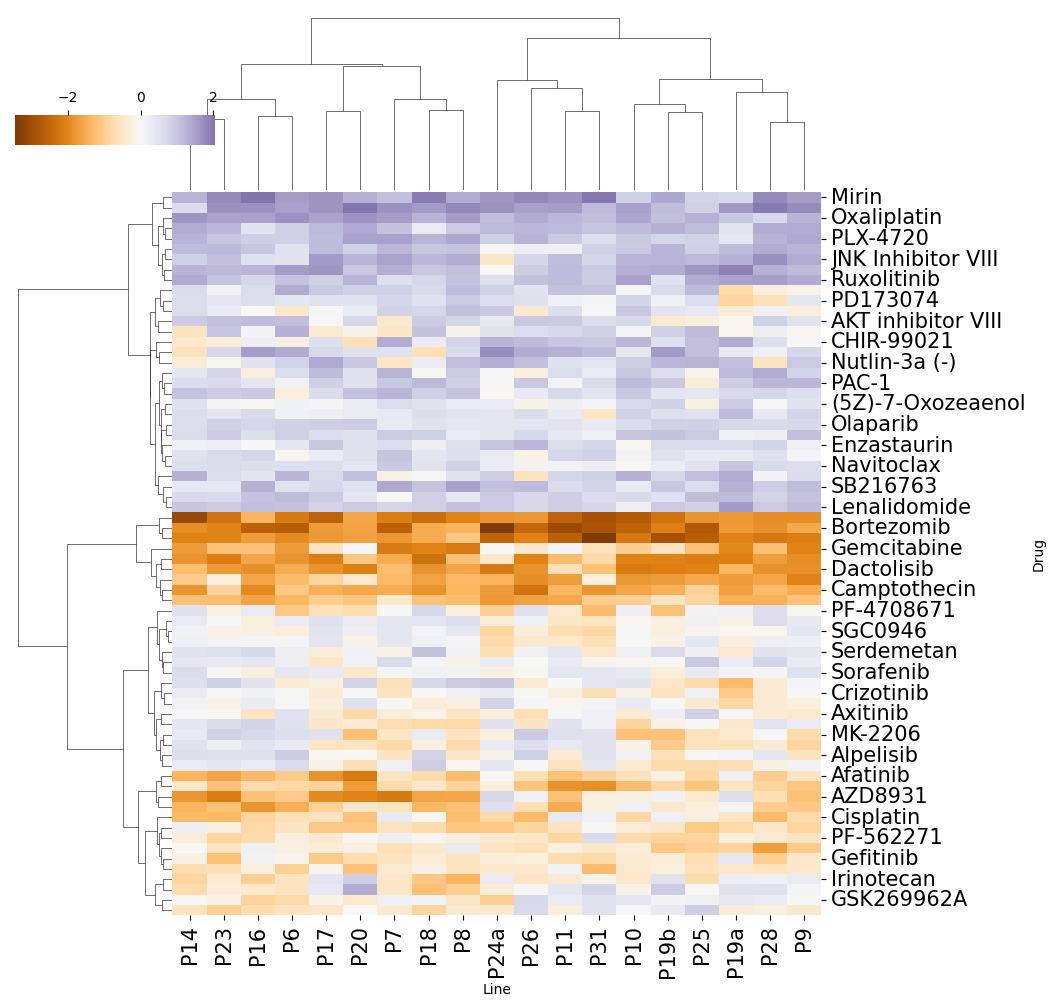

In [216]:
# unique_class = wnt_moa.MoA.unique()
# palette = sns.color_palette("Accent", len(unique_class))
# palette = [
#     "#a6cee3", #light sky blue
#     "#b2df8a" # light olive green
# ] 

# map = dict(zip(unique_class, palette))
# row_color = wnt_moa.set_index("drug")["MoA"].map(map)

g = sns.clustermap(
    map_ic50,
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr",
    standard_scale=None,
    z_score=1,
    center=0,
    method="ward",
    metric="euclidean",
    xticklabels=True,
    # row_colors=row_color,
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.85, 0.2, 0.03),
    figsize=(10,10)
)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), va='center')
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)

g

In [147]:
# g.savefig(
#     "slides/figures_regression/benchmark/ic50/HC_HNSC_IC50s.pdf"
# )